# 3 MNIST Fashion Multiclass Classification - Exercise

Goal of this notebook is to let you create your own neural net for multiclass classification. This dataset is a bit more suited to neural nets than the titanic dataset, so it should be a bit more representative. 

I will guide you with text on what you should do next, but providing the code is up to you. 

It is recommended to use the notebook 2 as a guideline, to copy paste code snippets from. 

In [3]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten, Input

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
print("Hello world")

Hello world


First, we download the data from the standard Keras Library. We use a build in function to split the data into the four required variables:

In [4]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 24s 1us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Print out the shapes of the four variables we just created. 

In [5]:
print(max(y_train))

9


In [6]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


You should be able to answer: 
* How many training samples do we have?
* How many test samples do we have?
* What is the shape of a single image?

Print out the first image from the training set, to see some of the numbers in there. 

In [7]:
#print(X_train[0])
print(y_train[0])

9


Check if the labels are numeric: 

In [8]:
print(y_train.dtype)

uint8


We can plot a single image as follows: 

9


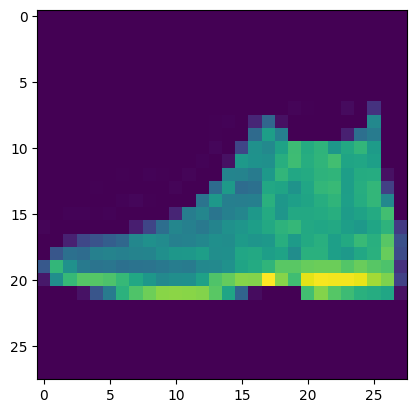

In [9]:
plt.figure()
print(y_test[0])
plt.imshow(X_test[0])

plt.show()

The pixel values in the images are currently scaled between 0 and 255. It is better for Gradient Descent when these values are scaled between 0 and 1. Therefore, in the next step, normalize your images by dividing the numpy array by 255. Print out the first image from the training set to see if the values are indeed between 0 and 1.

In [10]:
X_train = X_train/255
X_test = X_test/255
print(X_train[0])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.00392157 0.    

## Create your model architecture
Now, in the next cell(s), create your model architecture, using the sequential API from Keras. You can decide yourself how many layers and nodes you like.

Hint: As a first layer, you should use the "Flatten" layer, to transform the two dimensional input into a "regular" dense layer. 

Hint 2: For your output layer, you have a multiclass classification. Take care to use the correct number of nodes, and the right activation function. 

In [11]:
model = Sequential([
    Input(shape=(28, 28)),     # images are 28x28
    Flatten(),                 # becomes 784
    Dense(64, activation='relu'),
    Dense(128
          , activation='relu'),
    Dense(10, activation='softmax')   # Fashion-MNIST has 10 classes
])

Compile your model architecture. Use Stochastic Gradient Descent and the correct loss function for this problem and shape of the Y variable. Use accuracy as a metric.


In [12]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

## Train your model
Now, you should be able to train your model, using the training data. You pick your own hyperparameters. Do this in the next cell. 

In [13]:
model.fit(X_train, y_train, epochs=50, batch_size=64)

Epoch 1/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.8150 - loss: 0.5322
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8604 - loss: 0.3862
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8752 - loss: 0.3434
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8831 - loss: 0.3228
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8878 - loss: 0.3033
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8929 - loss: 0.2893
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8958 - loss: 0.2794
Epoch 8/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8996 - loss: 0.2692
Epoch 9/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9037 - loss: 0.2582
Epoch 10/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9055 - loss: 0.2519
Epoch 11/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9084 - loss: 0.2443
Epoch 12/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/ste

## Evaluate your model
After training your model, you should evaluate how well you did. First compute the loss and accuracy for the test set. 

In [14]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8870 - loss: 0.5139


[0.5139356255531311, 0.8870000243186951]

You should be able to answer: Was your model overfitting or underfitting?

Next, use the predict function to inference the model on your test data. Store the output in a variable.

In [15]:
p=model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Print the shape of the output, as well as the first 10 values. Compare this to the format of the labels.

In [16]:
print("Output shape:")
print(p.shape)
print("Output first 10 values:")
print(p[:10])
print(f"Max of first image: {max(p[0])} = Class {np.argmax(p[0])}")
print("Labels first 10 values:")
print(y_test[:10])

Output shape:
(10000, 10)
Output first 10 values:
[[1.71861470e-09 5.19493653e-07 1.53188895e-09 8.90056953e-08
  8.99984420e-10 4.33857494e-05 8.78539186e-11 2.08186175e-05
  1.96576302e-08 9.99935269e-01]
 [6.66684571e-07 5.81588649e-22 9.97526705e-01 1.41770971e-18
  2.47219950e-03 9.43290368e-13 4.78098400e-07 1.18784459e-17
  2.28684073e-14 2.47509529e-17]
 [1.31232240e-28 1.00000000e+00 1.23062733e-29 2.64329822e-29
  7.08106136e-31 0.00000000e+00 1.23861812e-24 0.00000000e+00
  2.66847317e-30 0.00000000e+00]
 [3.49253809e-24 1.00000000e+00 2.48663433e-24 1.00481571e-20
  1.00483421e-21 0.00000000e+00 3.57562811e-20 1.33853395e-33
  3.73776125e-27 0.00000000e+00]
 [1.29246131e-01 8.86612084e-17 2.55388720e-03 7.42909424e-06
  5.76348393e-05 4.77838201e-13 8.68134856e-01 9.52623439e-16
  5.44149578e-12 9.49833609e-15]
 [3.38618001e-25 1.00000000e+00 2.55826397e-27 3.93328002e-28
  3.10169031e-29 0.00000000e+00 2.29249148e-23 0.00000000e+00
  5.18086815e-25 0.00000000e+00]
 [1.7473

Now create a confusion matrix from this. Note that is will be slightly more difficult than with binary classification, since you need to convert each prediction list into a single number. 

Hint: Each prediction is a numpy array of 10 values. For each of these predictions, we need to extract the index number that has the highest value in it. 

Maybe this link will help: 
https://numpy.org/doc/stable/reference/generated/numpy.argmax.html 


[9 2 1 1 6 1 4 6 5 7]


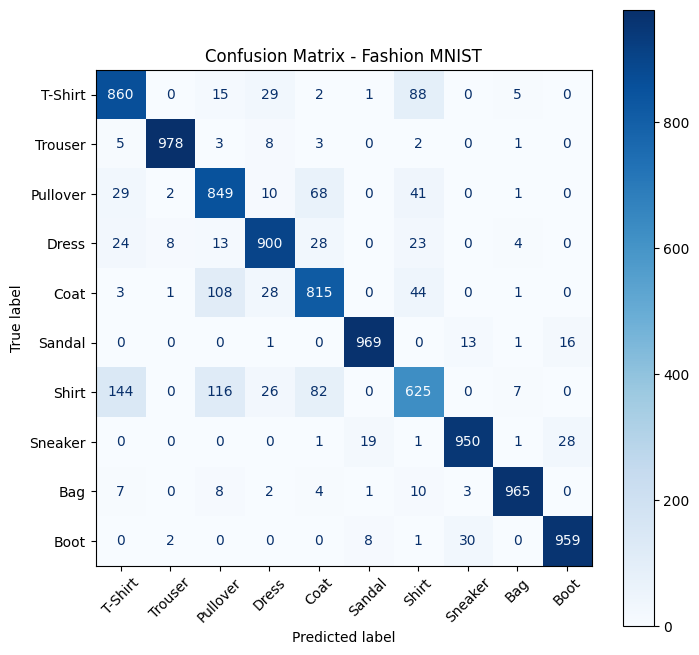

In [17]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Convert probabilities to predicted classes
y_pred = np.argmax(p, axis=1)
print(y_pred[0:10])


# Define class labels
class_names = ["T-Shirt", "Trouser", "Pullover", "Dress", "Coat", 
               "Sandal", "Shirt", "Sneaker", "Bag", "Boot"]

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot with labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8,8))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45, ax=ax, colorbar=True)
plt.title("Confusion Matrix - Fashion MNIST")
plt.show()


Congratulations, you have completed the exercise! If you have time left, you could pretty print the confusion matrix with the correct string labels.

In [18]:
# There are 10 classes, here are some string labels for them:
class_names = ["T-Shirt", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Boot"]